## Workflow



| Steps   |      description     |  metric |
|----------|:-------------:|------:|
| Order received | Day 1 |  Number of Orders, percentage of correct filled orders   |
| Order processing and shipping phase |    normally 2 Days, limited visibility   |   percentage of right processing, preparation/processing time, packaging time,  total shipping time |
| order shipped | delivered by external truck comapny on following day if possible, limited visibility |  delivery time  |
|delivered | customer received order, average 3 days time, unclear if thats true due to qr scan | total order time
    


------------------------------------------------------------
- claim:  complete data on the **Order Date** and the On **Truck Scan Date** --> check if its true.  

- but:  limited visibility of what happens in between or after --> when the truck leaves its unknown how much time it takes. 

- they have sent into the warehouse to record the **Ready to Ship Date** for as many orders as possible -> missing values


Dates ordered

1. Order Date from Orders

2. Order Date from Order Process Data - from the warehouse, is it the same as from orders? Customers can send orders every day, but the WH only operates from Mon. to Fri.. Orders received on weekends are processed on Monday.

3. Ready to Ship Date from InternStudy Data - ready to ship at warehouse

4. On Truck Scan Date from Order Process Date - order picked up by logisticks company?

4. Pickup Date from InternStudy Data - actual pick up from warehouse, does this match day reported from logistics company?

5. Arrival Scan Date from Campaing Data - the day customer scans and claims order arrived, not regular only done through promotion

Updated
# Hypotheses
1. **Limited visibility**: The company has limited data on the shipping and delivery stages, making it difficult to accurately assess the full delivery process. --included
2. **Warehouse processing time**: Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average. --included
3. **Express orders**: Express orders are processed and shipped significantly faster than standard orders.  --included
4. **Weekend orders** take longer to process than weekday orders. -inclueded
5. **Orders ready on Friday** experience longer waiting times because trucks leave only on Monday, Wednesday, and Friday. - delivery time by day of the order -> if Monday, but then, focus on weekdays Fruzsi
6. **Some orders** miss the next available truck. -open difference between ready for ship and pick up time, from Internstudy, Lauritz already calulated it
7. **Transportation** takes approximately three days after shipment. 
8. **Most variation in delivery time** comes from warehouse processing or waiting for a truck. -included
9. **Daily pickups** would reduce total delivery time. -included
10. **Processing all orders** as Express would improve delivery performance. mang do it now

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
orders_raw = pd.read_excel('../data/Muesli Project raw data.xlsx', sheet_name='Orders', header = 1)
orders_raw.head()

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


In [25]:
orders_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Index           9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Mode       9994 non-null   str           
 4   Customer ID     9994 non-null   str           
 5   Customer Name   9994 non-null   str           
 6   Origin Channel  9994 non-null   str           
 7   Country/Region  9994 non-null   str           
 8   City            9994 non-null   str           
 9   State           9994 non-null   str           
 10  Postal Code     9983 non-null   float64       
 11  Region          9994 non-null   str           
 12  Category        9994 non-null   str           
 13  Sub-Category    9994 non-null   str           
 14  Product ID      9994 non-null   str           
 15  Sales          

In [26]:
orders_raw.isnull().sum()

Index              0
Order ID           0
Order Date         0
Ship Mode          0
Customer ID        0
Customer Name      0
Origin Channel     0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Category           0
Sub-Category       0
Product ID         0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [27]:
#To indentify the missing records
orders_raw[orders_raw['Postal Code'].isna()]

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
173,2235,CA-2020-104066,2020-12-05,Standard Class,QJ-19255,Quincy Jones,Sales,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Gluten Free,TEC-AC-10001013,205.03,7,0.0,67.6599
710,9147,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Gluten Free,TEC-AC-10002926,99.98,2,0.0,42.9914
1732,9389,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Mega Protein,OFF-AP-10000828,542.94,3,0.0,152.0232
3408,9387,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Nuts and more,OFF-PA-10000157,79.92,4,0.0,37.5624
3409,9388,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Nuts and more,OFF-PA-10001970,12.28,1,0.0,5.7716
4279,8799,US-2019-150140,2019-04-06,Standard Class,VM-21685,Valerie Mitchum,Facebook,United States,Burlington,Vermont,NaN,East,Special Projects Muesil,Only Oats,TEC-PH-10002555,1294.75,5,0.0,336.6350
4694,9390,US-2020-127292,2020-01-19,Standard Class,RM-19375,Raymond Messe,Email,United States,Burlington,Vermont,NaN,East,Power Muesli,Power Clean Fibre Boost,OFF-EN-10001509,2.04,1,0.0,0.9588
5490,9149,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Power Muesli,Steel Cut,OFF-ST-10001526,1564.29,13,0.0,406.7154
7802,9148,US-2019-165505,2019-01-23,Standard Class,CB-12535,Claudia Bergmann,Sales,United States,Burlington,Vermont,NaN,East,Power Muesli,Super Mega Protein,OFF-AR-10003477,8.04,6,0.0,2.7336
8415,9742,CA-2018-117086,2018-11-08,Standard Class,QJ-19255,Quincy Jones,Sales,United States,Burlington,Vermont,NaN,East,Toasted Muesli,With Fruit,FUR-BO-10004834,4404.90,5,0.0,1013.1270


In [29]:
#To look for the same city or elsewhere in the dataset to fill in the missing value. 

orders_raw[orders_raw["City"].eq("Burlington") & orders_raw["State"].eq("Vermont")]["Postal Code"].unique()

array([nan])

**I cannot get the value to fill in the missing value from the dataset.**

In [32]:
#To fill in the postal code with the one that I find in google.
# Missing postal codes for Burlington, Vermont were imputed using an external geographic reference.

orders_raw['Postal Code'] = orders_raw['Postal Code'].astype('string')

orders_raw.loc[
    orders_raw['Postal Code'].isna(),
    'Postal Code'
] = '05401'

In [33]:
orders_raw.isnull().sum()

Index             0
Order ID          0
Order Date        0
Ship Mode         0
Customer ID       0
Customer Name     0
Origin Channel    0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Category          0
Sub-Category      0
Product ID        0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [34]:
orders_raw.duplicated().sum()

np.int64(0)

In [35]:

#To fix the data types

orders_raw['Order Date'] = pd.to_datetime(orders_raw['Order Date'])

orders_raw['Sales'] = pd.to_numeric(orders_raw['Sales'])
orders_raw['Quantity'] = pd.to_numeric(orders_raw['Quantity'])
orders_raw['Discount'] = pd.to_numeric(orders_raw['Discount'])
orders_raw['Profit'] = pd.to_numeric(orders_raw['Profit'])

In [36]:
orders_raw.dtypes

Index                      int64
Order ID                     str
Order Date        datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Origin Channel               str
Country/Region               str
City                         str
State                        str
Postal Code               string
Region                       str
Category                     str
Sub-Category                 str
Product ID                   str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [40]:
orders_raw['Ship Mode'].value_counts()

orders_raw['Origin Channel'].value_counts()

orders_raw['Region'].value_counts()

orders_raw['Category'].value_counts()


Category
Power Muesli               6026
Toasted Muesli             2121
Special Projects Muesil    1847
Name: count, dtype: int64

In [ ]:
#to check whether your identifiers behave as expected

orders_raw['Order ID'].nunique()

5009

In [18]:

orders_raw['Customer ID'].nunique()

793

In [19]:

orders_raw['Product ID'].nunique()

1862

In [41]:
orders_raw.columns = (
    orders_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)

orders_raw.head()

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
0,27,CA-2019-121755,2019-01-16,Second Class,EH-13945,Eric Hoffmann,Email,United States,Los Angeles,California,90049.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10003027,90.57,3,0.0,11.7741
1,45,CA-2019-118255,2019-03-11,First Class,ON-18715,Odella Nelson,Sales,United States,Eagan,Minnesota,55122.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10000171,45.98,2,0.0,19.7714
2,48,CA-2019-169194,2019-06-20,Standard Class,LH-16900,Lena Hernandez,Email,United States,Dover,Delaware,19901.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,45.00,3,0.0,4.9500
3,60,CA-2019-111682,2019-06-17,First Class,TB-21055,Ted Butterfield,Email,United States,Troy,New York,12180.0,East,Special Projects Muesil,Gluten Free,TEC-AC-10002167,30.00,2,0.0,3.3000
4,63,CA-2018-135545,2018-11-24,Standard Class,KM-16720,Kunst Miller,Email,United States,Los Angeles,California,90004.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10004633,13.98,2,0.0,6.1512


**Checking numerical range and outlier**

In [44]:
Q1 = orders_raw['sales'].quantile(0.25)
Q3 = orders_raw['sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Sales lower bound:", lower)
print("Sales upper bound:", upper)

orders_raw[['sales', 'quantity', 'discount', 'profit']].describe() 

Sales lower bound: -271.71000000000004
Sales upper bound: 498.93


,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [57]:
orders_raw[orders_raw['sales'] < 0] #to check suspicious value

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


In [58]:
orders_raw[orders_raw['quantity'] <= 0]

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


In [59]:
orders_raw[orders_raw['discount'] < 0]

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


In [60]:
orders_raw[orders_raw['discount'] > 1]

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit


In [61]:

orders_raw[orders_raw['profit'] < 0]

,index,order_id,order_date,ship_mode,customer_id,customer_name,origin_channel,country_region,city,state,postal_code,region,category,sub_category,product_id,sales,quantity,discount,profit
6,101,CA-2019-158568,2019-08-29,Standard Processing,RB-19465,Rick Bensley,Facebook,United States,Chicago,Illinois,60610.0,Central,Special Projects Muesil,Gluten Free,TEC-AC-10001767,95.976,3,0.2,-10.7973
7,104,US-2018-156867,2018-11-13,Standard Processing,LC-16870,Lena Cacioppo,Email,United States,Aurora,Colorado,80013.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10001552,238.896,6,0.2,-26.8758
16,236,US-2020-100930,2020-04-07,Standard Processing,CS-12400,Christopher Schild,Facebook,United States,Tampa,Florida,33614.0,South,Special Projects Muesil,Gluten Free,TEC-AC-10003832,617.976,3,0.2,-7.7247
27,376,US-2017-119137,2017-07-23,Standard Processing,AG-10900,Arthur Gainer,Email,United States,Tucson,Arizona,85705.0,West,Special Projects Muesil,Gluten Free,TEC-AC-10002076,479.040,10,0.2,-29.9400
29,386,US-2018-168935,2018-11-27,Standard Processing,DO-13435,Denny Ordway,Email,United States,Pembroke Pines,Florida,33024.0,South,Special Projects Muesil,Gluten Free,TEC-AC-10002335,83.976,3,0.2,-1.0497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9982,9791,CA-2020-144491,2020-03-27,Standard Processing,CJ-12010,Caroline Jumper,Email,United States,Houston,Texas,77070.0,Central,Toasted Muesli,With Nuts,FUR-CH-10001714,211.246,2,0.3,-66.3916
9983,9793,CA-2017-127166,2017-05-21,Express,KH-16360,Katherine Hughes,Email,United States,Houston,Texas,77070.0,Central,Toasted Muesli,With Nuts,FUR-CH-10003396,107.772,2,0.3,-29.2524
9985,9827,US-2017-164406,2017-08-15,Standard Processing,BD-11605,Brian Dahlen,Email,United States,San Francisco,California,94122.0,West,Toasted Muesli,With Nuts,FUR-CH-10003833,195.136,4,0.2,-12.1960
9991,9913,CA-2018-132388,2018-10-10,Express,KN-16390,Katherine Nockton,Sales,United States,Santa Barbara,California,93101.0,West,Toasted Muesli,With Nuts,FUR-CH-10001714,362.136,3,0.2,-54.3204


In [65]:
#to check repeated orders

orders_raw['order_id'].value_counts().head(10)

order_id
CA-2020-100111    14
CA-2020-157987    12
CA-2019-165330    11
US-2019-108504    11
CA-2018-131338    10
US-2018-126977    10
CA-2019-105732    10
CA-2020-117457     9
CA-2017-106439     9
CA-2020-140949     9
Name: count, dtype: int64

**To know how many unique orders each customer has?**

In [66]:
#To check whether the customer has multiple orders

orders_raw.groupby('customer_id')['order_id'].nunique().describe()

count    793.000000
mean       6.316520
std        2.550885
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: order_id, dtype: float64

**Count means number of unique customers. The average number of orders per customer is 6. Customers' order counts vary with 2.5. Customer with the fewest orders is 1. and customer with the most orders is 17. Median number of orders is 6. 25% of customers have 5 orders or fewer, and 75% of customers have 8 orders or fewer.**

# Sheet 2, Campain Dataset

In [3]:
campaign_raw = pd.read_excel('../data/Muesli Project raw data.xlsx', sheet_name='Campaign Data')
campaign_raw.head()

,Order ID,Arrival Scan Date,Customer Name
0,CA-2019-109666,2019-05-03,Kunst Miller
1,CA-2019-138933,2019-05-03,Jack Lebron
2,CA-2019-130001,2019-05-03,Heather Kirkland
3,CA-2019-113061,2019-05-06,Ed Ludwig
4,CA-2019-162138,2019-05-06,Grace Kelly


**The arrival scan date means the exact delivery date when the order finally arrives at the customer's location.**

In [46]:
# Your code here — .info(), .describe()               #the company said data over past few years, its only 1 year
campaign_raw.info()
display(campaign_raw.describe())

<class 'pandas.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           333 non-null    str           
 1   Arrival Scan Date  333 non-null    datetime64[us]
 2   Customer Name      333 non-null    str           
dtypes: datetime64[us](1), str(2)
memory usage: 7.9 KB


,Arrival Scan Date
count,333
mean,2019-10-14 19:36:12.972973
min,2019-05-03 00:00:00
25%,2019-09-09 00:00:00
50%,2019-10-21 00:00:00
75%,2019-12-16 00:00:00
max,2020-05-15 00:00:00


In [47]:
campaign_raw.isnull().sum() #no missing values

Order ID             0
Arrival Scan Date    0
Customer Name        0
dtype: int64

In [48]:
campaign_raw.duplicated().sum() #no duplicates either

np.int64(0)

# Sheet 3, Order Processing Raw 

In [4]:
import pandas as pd
order_process_raw = pd.read_excel('../data/Muesli Project raw data.xlsx', sheet_name='Order Process Data')
order_process_raw.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


**The On Truck Scan Date represents the exact date when an order physically leaves the Muesli company's warehouse inside a delivery truck.**

**Unlike other steps in the process, the company has complete, fully-tracked data for this date across all transactions over the past few years.**

**Logistics Schedule: Trucks only leave the warehouse on Mondays, Wednesdays, and Fridays.**

**Standard Process: Orders are normally scanned onto the truck the day after they are marked as ready for shipping (or two days later if no truck is scheduled for that day).**

**Express Process: If a customer pays for Express Processing, the order bypasses the standard delay and leaves on a truck the exact same day it becomes ready for shipping.**

In [28]:
order_process_raw.shape

(5899, 5)

In [29]:
order_process_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   str           
 2   Order Date          5899 non-null   datetime64[us]
 3   On Truck Scan Date  5899 non-null   datetime64[us]
 4   Ship Mode           5899 non-null   str           
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 230.6 KB


In [30]:
order_process_raw.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
On Truck Scan Date    0
Ship Mode             0
dtype: int64

In [31]:
order_process_raw.duplicated().sum()

np.int64(0)

In [50]:
order_process_raw.columns = (
    order_process_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)

order_process_raw.head()

,row_id,order_id,order_date,on_truck_scan_date,ship_mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


**To change to correct datetime**

**To check the date range and temporal data-quality check to make sure whether the date make sense before calculating processing time.**

In [33]:
order_process_raw['order_date'] = pd.to_datetime(order_process_raw['order_date'])

order_process_raw['on_truck_scan_date'] = pd.to_datetime(order_process_raw['on_truck_scan_date'])

print("Order date:")
print(order_process_raw['order_date'].min())
print(order_process_raw['order_date'].max())

print("\nTruck scan date:")
print(order_process_raw['on_truck_scan_date'].min())
print(order_process_raw['on_truck_scan_date'].max())

Order date:
2019-01-02 00:00:00
2020-12-30 00:00:00

Truck scan date:
2019-01-07 00:00:00
2021-01-06 00:00:00


**Orders in this dataset were placed between January 2, 2019 and December 30, 2020.Orders were scanned onto the truck between January 7, 2019 and January 6, 2021.The truck scan date extending into January 2021 makes sense, because orders placed at the end of December 2020 could be processed and scanned in early January 2021.So there is no obvious problem with the overall date range.**

# **To check for invalid dates to make sure no order was scanned before it was ordered.**

In [34]:
invalid_dates = order_process_raw[
    order_process_raw['on_truck_scan_date'] < order_process_raw['order_date']
]

len(invalid_dates)

0

**There is no order that was scanned before it was orders.**

# **Hypothesis 2**: **Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average.**

# **To calculate warehouse processing time**

In [35]:
order_process_raw['processing_days'] = (
    order_process_raw['on_truck_scan_date'] -
    order_process_raw['order_date']
).dt.days

In [37]:
order_process_raw[['order_date', 'on_truck_scan_date', 'processing_days']].head()

,order_date,on_truck_scan_date,processing_days
0,2019-01-03,2019-01-07,4
1,2019-01-02,2019-01-09,7
2,2019-01-02,2019-01-09,7
3,2019-01-03,2019-01-09,6
4,2019-01-03,2019-01-09,6


In [39]:
order_process_raw['processing_days'].describe()

count    5899.000000
mean        6.120529
std         2.509031
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        12.000000
Name: processing_days, dtype: float64

**Median processing time = 7 days, meaning 50% of the orders took 7 days or more. Average processing time = 6.12 days, but the target is 2 days. The average order is taking about 3.06 times longer than the 2-day target. So based on the current data, the warehouse is not normally processing orders within 2 days.**

**To check 2 days target**

In [40]:
order_process_raw['within_2_days'] = (
    order_process_raw['processing_days'] <= 2
)

In [41]:
order_process_raw['within_2_days'].value_counts()

within_2_days
False    5277
True      622
Name: count, dtype: int64

In [42]:
order_process_raw['within_2_days'].mean() * 100

np.float64(10.54416002712324)

**This means only 10.54% of the orders were processed within 2 days.**

**How many orders miss the target?**

In [43]:
orders_over_2_days = (
    order_process_raw['processing_days'] > 2
).sum()

orders_over_2_days

orders_over_2_days / len(order_process_raw) * 100

np.float64(89.45583997287676)

# **Hypothesis 4**: **Express orders are processed and shipped significantly faster than standard orders.**

**This means 89% of the orders miss the target processing day.**

**To analyze processing time by Ship Mode, because different shipping methods may have different warehouse processing patterns.**

In [44]:
order_process_raw.groupby('ship_mode')['processing_days'].describe()

,count,mean,std,min,25%,50%,75%,max
ship_mode,,,,,,,,
Express,1303.0,2.568688,1.638534,0.0,1.0,3.0,4.0,6.0
Standard Processing,4596.0,7.127502,1.651674,2.0,6.0,7.0,8.0,12.0


In [22]:
order_process_raw.groupby('ship_mode')['within_2_days'].mean() * 100

ship_mode
Express                47.659248
Standard Processing     0.021758
Name: within_2_days, dtype: float64

**This means with Express: about 47.66% of orders met the 2-day target. With Standard Processing: only about 0.02% met the 2-day target.**

**Boxplot: Express versus Standard orders**

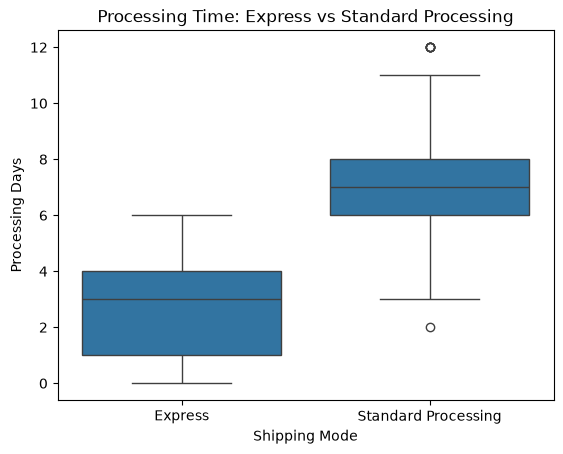

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=order_process_raw,
    x='ship_mode',
    y='processing_days'
)

plt.title('Processing Time: Express vs Standard Processing')
plt.xlabel('Shipping Mode')
plt.ylabel('Processing Days')
plt.show()

**(Optional)To identify extreme delays**

In [24]:
Q1 = order_process_raw['processing_days'].quantile(0.25)
Q3 = order_process_raw['processing_days'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 5.0
Q3: 8.0
IQR: 3.0
Lower bound: 0.5
Upper bound: 12.5


**25% of the orders took 5 days or less, and 75% of the orders took 8 days or less. The middle 50% of orders are processed within a range of about 3 days, from 5 to 8 days.**

In [27]:
outliers = order_process_raw[
    (order_process_raw['processing_days'] < lower_bound) |
    (order_process_raw['processing_days'] > upper_bound)
]

outliers
len(outliers)

152

In [28]:
# to inspect the outlier

outliers[
    ['order_id',
     'order_date',
     'on_truck_scan_date',
     'ship_mode',
     'processing_days']
].sort_values('processing_days', ascending=False)

,order_id,order_date,on_truck_scan_date,ship_mode,processing_days
179,CA-2019-106306,2019-03-08,2019-03-08,Express,0
4021,US-2020-118941,2020-08-12,2020-08-12,Express,0
3748,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3749,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3768,US-2020-152492,2020-07-06,2020-07-06,Express,0
...,...,...,...,...,...
2275,US-2019-148803,2019-12-11,2019-12-11,Express,0
2276,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2277,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2278,CA-2019-162187,2019-12-11,2019-12-11,Express,0


**To analyze the distribution**

**To check how many orders took each exact number of days to process.**


In [45]:
order_process_raw['processing_days'].value_counts().sort_index()

KeyError: 'processing_days'

**152 orders were completed on the same date they were received**

In [30]:
#To show inn percentage
order_process_raw['processing_days'].value_counts(
    normalize=True
).sort_index() * 100

processing_days
0      2.576708
1      4.204102
2      3.763350
3      6.323106
4      7.374131
5     10.205120
6     12.968300
7     19.749110
8     17.324970
9      9.577895
10     5.390744
11     0.440753
12     0.101712
Name: proportion, dtype: float64

In [ ]:
order_process_raw.to_excel(
    'order_process_cleaned.xlsx',
    index=False
)

In [44]:
order_process_raw['processing_days'].describe()

KeyError: 'processing_days'

**To create visualization**

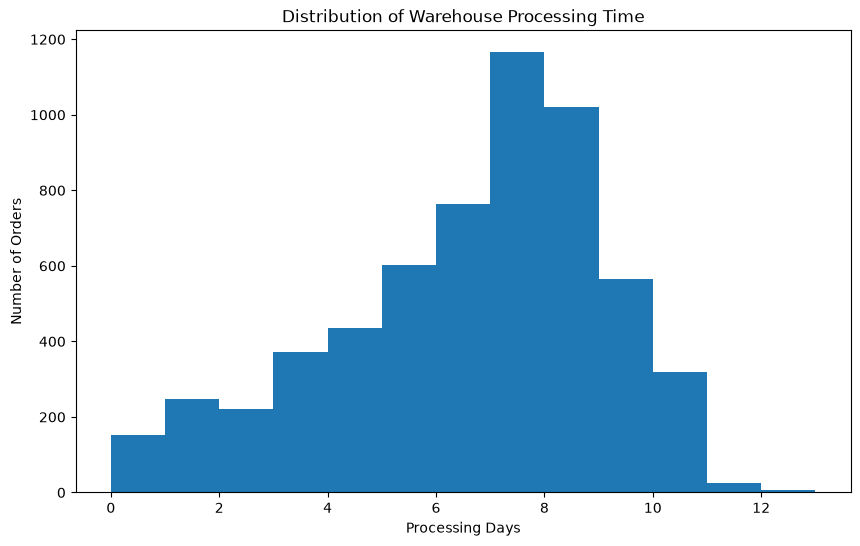

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(order_process_raw['processing_days'], bins=range(
    order_process_raw['processing_days'].min(),
    order_process_raw['processing_days'].max() + 2
))
plt.xlabel('Processing Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Warehouse Processing Time')
plt.show()

# **Hypothesis 6:**

**Weekend orders take longer to process than weekday orders.**

**To check weekend orders take longer to process than weekday orders.**

**First, creating the Weekend and Weekday column**

In [43]:
order_process_raw['order_date'] = pd.to_datetime(order_process_raw['order_date'])

order_process_raw['day_type'] = order_process_raw['order_date'].dt.dayofweek.map(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

**0 is Monday and 6 is Sunday**

In [44]:
# To compare average processing time

order_process_raw.groupby('day_type')['processing_days'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
day_type,,,
Weekday,4981,5.974704,7.0
Weekend,918,6.911765,8.0


**Weekend orders take longer to process than weekday orders because their average processing time is higher (6.9 vs. 5.9 days) and their median processing time is also higher (8 vs. 7 days).**

**(Optional)To check weekend or weekday order meet the 2 days target?**

In [45]:
order_process_raw.groupby('day_type')['within_2_days'].mean() * 100

day_type
Weekday    11.584019
Weekend     4.901961
Name: within_2_days, dtype: float64

**11% of Weekday orders meet the 2 day targer.**

**Distribution of processing time between two groups**

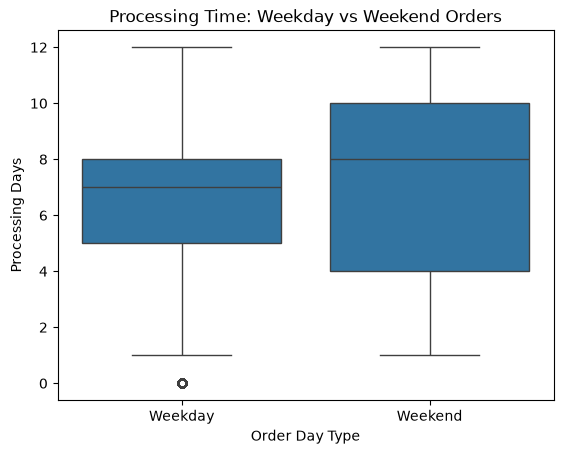

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=order_process_raw,
    x='day_type',
    y='processing_days'
)

plt.title('Processing Time: Weekday vs Weekend Orders')
plt.xlabel('Order Day Type')
plt.ylabel('Processing Days')
plt.show()

# Sheet 4

In [5]:
import pandas as pd

intern_data_study = pd.read_excel('../data/Muesli Project raw data.xlsx', sheet_name='InternData Study')
intern_data_study.head()

,Order ID,Ready to Ship Date,Pickup Date
0,CA-2019-116540,2019-09-02,2019-09-03
1,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06


In [20]:
# Check the 'Intern Data Study' File

intern_data_study.shape # 290 rows, 3 columns

(204, 3)

In [21]:
# ready to ship and Pickup Date are datetime and Ordr Id is object
intern_data_study.dtypes

order_id                         str
ready_to_ship_date    datetime64[us]
pickup_date           datetime64[us]
dtype: object

In [22]:
intern_data_study.isnull().sum()

order_id              0
ready_to_ship_date    0
pickup_date           0
dtype: int64

In [38]:
intern_data_study.describe()

,Ready to Ship Date,Pickup Date
count,290,290
mean,2020-06-18 15:08:41.379310,2020-06-20 06:47:10.344827
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-23 00:00:00,2019-09-23 12:00:00
50%,2020-11-10 00:00:00,2020-11-12 00:00:00
75%,2020-11-23 00:00:00,2020-11-23 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


In [34]:
# there are 86 duplicated rows in the dataset

intern_data_study.duplicated().sum()

np.int64(86)

**Here 86 rows that are exact repetitions (same information) of another row. If the same order appears five times with exactly the same dates, that means I have one order that was accidentally recorded five times. The duplicate order can artificially increase the average. Original was (290, 3), but 86 duplicates, after removing, it was (204, 3). This is reasonable if each row is supposed to represent one unique order. Are these repeated rows actually errors, or are they legitimate repeated observations? **

In [8]:
intern_data_study.columns = (
    intern_data_study.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)

intern_data_study.head()

,order_id,ready_to_ship_date,pickup_date
0,CA-2019-116540,2019-09-02,2019-09-03
1,CA-2019-116540,2019-09-02,2019-09-03
2,CA-2019-129847,2019-09-04,2019-09-04
3,CA-2019-129630,2019-09-04,2019-09-04
4,CA-2019-106278,2019-09-05,2019-09-06


## Checking duplicates

**First, to inspect the duplicated rows before deleting it**

**To verify the duplicates**

In [9]:
# To check if the duplicate rows are exactly identical
# I used keep=False marks all instances of duplicated rows, not just the second occurrence.

duplicates = intern_data_study[
    intern_data_study.duplicated(keep=False)
].sort_values('order_id')

duplicates

,order_id,ready_to_ship_date,pickup_date
78,CA-2019-100244,2019-09-24,2019-09-25
79,CA-2019-100244,2019-09-24,2019-09-25
80,CA-2019-100244,2019-09-24,2019-09-25
82,CA-2019-100244,2019-09-24,2019-09-25
83,CA-2019-100244,2019-09-24,2019-09-25
...,...,...,...
152,US-2020-155425,2020-11-11,2020-11-12
225,US-2020-155866,2020-11-23,2020-11-25
215,US-2020-155866,2020-11-23,2020-11-25
107,US-2020-163790,2020-11-04,2020-11-06


In [39]:
# to check how many rows remain after removing duplicates
intern_data_study.shape

(290, 3)

In [10]:
intern_data_study = intern_data_study.drop_duplicates()

In [11]:
intern_data_study.duplicated().sum()

np.int64(0)

In [46]:
intern_data_study.shape

(204, 3)

**Before and after removing duplicates, I still get 290 rows. All 290 rows in the dataset are part of a duplicated group. In other words, there are no rows that are unique across all 3 columns.**

In [63]:
# latest Pickup date in the dataset
max_date_pickup = intern_data_study['Pickup Date'].max()
max_date_pickup

Timestamp('2020-12-09 00:00:00')

In [64]:
# earliest Pickup date in the dataset
min_date_pickup = intern_data_study['Pickup Date'].min()
min_date_pickup

Timestamp('2019-09-03 00:00:00')

In [65]:
# 463 days timespan
time_differnce = max_date_pickup - min_date_pickup
time_differnce

Timedelta('463 days 00:00:00')

In [66]:
# calculate delivery time in days between ready to ship and pickup; make it more accurate and use hours?

intern_data_study['storagetime'] = intern_data_study['Pickup Date'] - intern_data_study['Ready to Ship Date']
intern_data_study['storagetime']

0     1 days
2     0 days
3     0 days
4     1 days
5     1 days
       ...  
283   1 days
284   3 days
285   3 days
288   3 days
289   2 days
Name: storagetime, Length: 204, dtype: timedelta64[us]

In [67]:
# create updated dataset with delivery time column
intern_data_study.to_excel('updated_intern_data_study.xlsx', index=False)

In [68]:
# how many orders per year
intern_data_study['Month-Year'] = intern_data_study['Pickup Date'].dt.to_period('M')
orders_per_month = intern_data_study.groupby('Month-Year')['Order ID'].count()
orders_per_month

Month-Year
2019-09     55
2019-10      9
2020-11    116
2020-12     24
Freq: M, Name: Order ID, dtype: int64

In [69]:
intern_data_study['Month-Year'].value_counts()

Month-Year
2020-11    116
2019-09     55
2020-12     24
2019-10      9
Freq: M, Name: count, dtype: int64

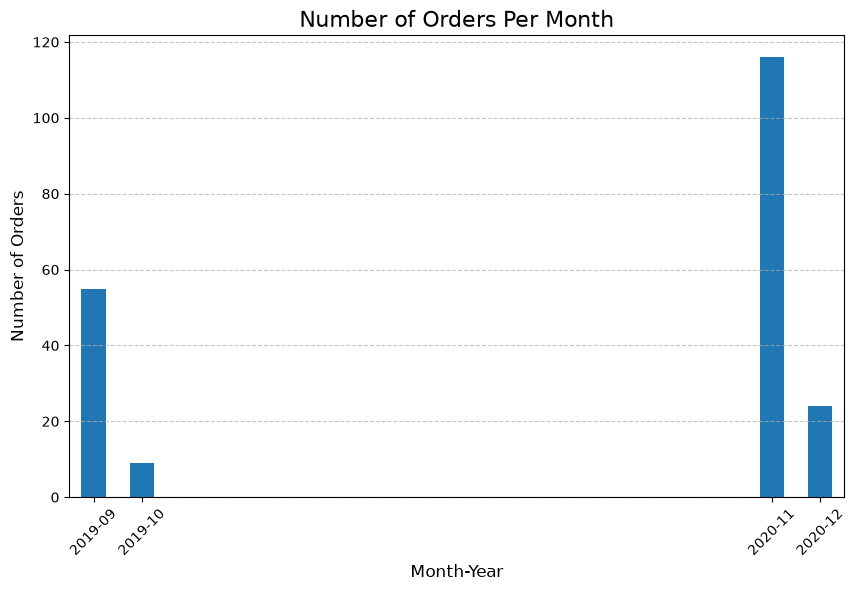

In [70]:
orders_per_month.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Orders Per Month', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# **Hypothesis 11:**

 **To check the most variation in delivery time comes from warehouse processing or waiting for a truck.**

In [71]:
# renaming
intern_data_study = intern_data_study.rename(
    columns={'Order ID': 'order_id'}
)

In [72]:
#merging
order_analysis = order_process_raw.merge(
    intern_data_study,
    on='order_id',
    how='inner'
)

In [73]:
#to check the date are actually date
date_columns = [
    'order_date',
    'Ready to Ship Date',
    'Pickup Date',
    'on_truck_scan_date'
]

for col in date_columns:
    order_analysis[col] = pd.to_datetime(
        order_analysis[col],
        errors='coerce'
    )

**To calculate warehouse processing time, Order placed → Ready to Ship**

In [74]:
order_analysis['warehouse_processing_days'] = (
    order_analysis['Ready to Ship Date']
    - order_analysis['order_date']
).dt.days

**To calculate waiting-for-pickup time, Ready to Ship → Pickup**

**This si the day waited for pickup**


In [75]:
order_analysis['waiting_for_pickup_days'] = (
    order_analysis['Pickup Date']
    - order_analysis['Ready to Ship Date']
).dt.days

**To compare the variation, to knwo whether the most variation in delivery time comes from warehouse processing or waiting for a truck.**

In [76]:
order_analysis[
    ['warehouse_processing_days', 'waiting_for_pickup_days']
].std()

warehouse_processing_days    1.949961
waiting_for_pickup_days      0.966945
dtype: float64

**Warehouse processing has greater variation than waiting for pickup because its standard deviation is higher.**

**To compare by using the mean**

In [77]:
order_analysis[
    ['warehouse_processing_days', 'waiting_for_pickup_days']
].mean()

warehouse_processing_days    4.157895
waiting_for_pickup_days      1.643541
dtype: float64

**On average, orders spend much more time being processed by the warehouse than waiting for pickup.**

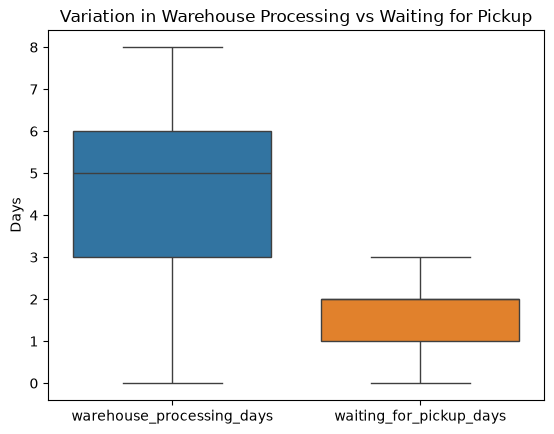

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=order_analysis[
        ['warehouse_processing_days', 'waiting_for_pickup_days']
    ]
)

plt.title('Variation in Warehouse Processing vs Waiting for Pickup')
plt.ylabel('Days')
plt.show()

# **Hypothesis 2**: **Orders are expected to be ready for shipping within 2 days, but the actual processing time may be longer on average.**

# **To calculate actual processing day**


In [12]:
processing_days = order_process_raw.merge(
    intern_data_study[['order_id', 'ready_to_ship_date', 'pickup_date']],
    on='order_id',
    how='left'
)

In [13]:
processing_days.head(2)

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,ready_to_ship_date,pickup_date
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express,NaT,NaT
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,NaT,NaT


**Keep all orders from order_process_raw, and add the matching dates from intern_study when they exist.**

In [14]:
# to make sure the dates are actual dates
processing_days['order_date'] = pd.to_datetime(
    processing_days['order_date']
)

processing_days['ready_to_ship_date'] = pd.to_datetime(
    processing_days['ready_to_ship_date']
)

In [15]:
# to check how many data actually match

common_ids = set(order_process_raw['order_id']) & set(intern_data_study['order_id'])

print("Orders in order_process_raw:", order_process_raw['order_id'].nunique())
print("Orders in intern_data_study:", intern_data_study['order_id'].nunique())
print("Matching orders:", len(common_ids))

Orders in order_process_raw: 3002
Orders in intern_data_study: 204
Matching orders: 204


In [16]:
# 1. Warehouse processing time
processing_days['processing_days'] = (
    processing_days['ready_to_ship_date'] -
    processing_days['order_date']
).dt.days

In [17]:
processing_days['processing_days'].describe()

count    418.000000
mean       4.157895
std        1.949961
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max        8.000000
Name: processing_days, dtype: float64

**For 418 orders, median processing time = 5 days, meaning 50% of the orders took 5 days or more. Average processing time = 4.15 days, but the target is 2 days. The average order is taking about 2 times longer than the 2-day target. So based on the current data, the warehouse is not normally processing orders within 2 days. But some orders were ready on the same recorded day**

In [18]:
# to check how many orders actually have processing time

processing_days['processing_days'].notna().sum()

np.int64(418)

In [19]:
# to check missing value percentage

processing_days['processing_days'].isna().mean() * 100

np.float64(92.9140532293609)